In [1]:
## importing necessary liabraries
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
%matplotlib inline


### Loading the breast cancer data set

In [12]:

df=load_breast_cancer()

### Creating independent and dependent **variables**

In [14]:
X=df.data
y=df.target


In [15]:
X[:,1]

array([10.38, 17.77, 21.25, 20.38, 14.34, 15.7 , 19.98, 20.83, 21.82,
       24.04, 23.24, 17.89, 24.8 , 23.95, 22.61, 27.54, 20.13, 20.68,
       22.15, 14.36, 15.71, 12.44, 14.26, 23.04, 21.38, 16.4 , 21.53,
       20.25, 25.27, 15.05, 25.11, 18.7 , 23.98, 26.47, 17.88, 21.59,
       21.72, 18.42, 25.2 , 20.82, 21.58, 21.35, 24.81, 20.28, 21.81,
       17.6 , 16.84, 18.66, 14.63, 22.3 , 21.6 , 16.34, 18.24, 18.7 ,
       22.02, 18.75, 18.57, 21.59, 19.31, 11.79, 14.88, 20.98, 22.15,
       13.86, 23.84, 23.94, 21.01, 19.04, 17.33, 16.49, 21.31, 14.64,
       24.52, 15.79, 16.52, 19.65, 10.94, 16.15, 23.97, 18.  , 20.97,
       15.86, 24.91, 26.29, 15.65, 18.52, 21.46, 24.59, 21.8 , 15.24,
       24.02, 22.76, 14.76, 18.3 , 19.83, 23.03, 17.84, 19.94, 12.84,
       19.77, 24.98, 13.43, 20.52, 19.4 , 19.29, 15.56, 18.33, 18.54,
       19.67, 21.26, 16.99, 20.76, 19.65, 20.19, 15.83, 21.53, 15.76,
       16.67, 22.91, 20.01, 10.82, 17.12, 20.2 , 10.89, 16.39, 17.21,
       24.69, 18.91,

## Splitting the data into training and testing set

In [16]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=24)
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

(455, 30) (455,)
(114, 30) (114,)


In [5]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=24)
print(f"Train Data: {X_train.shape},{y_train.shape}")
print(f"Test Data: {X_test.shape},{y_test.shape}")

Train Data: (455, 30),(455,)
Test Data: (114, 30),(114,)


# **Training a binary classifier and making Predictions**

In [17]:
classifier = RandomForestClassifier(random_state=24)
classifier.fit(X_train,y_train)
#predict
y_pred=classifier.predict(X_test)

# Evaluating the model
                      
##                      Accuracy=Total number of correctly predicted samples/Total number of **samples**

In [7]:
from sklearn.metrics import accuracy_score

In [9]:
accuracy = accuracy_score(y_test,predictions)*100
print(accuracy)

95.6140350877193


In [13]:
#print(f"Accuracy of the Classifier is:{accuracy_score(y_test,predictions)*100}%")

Accuracy of the Classifier is:95.6140350877193%


In [10]:
from sklearn.metrics import confusion_matrix
#from sklearn.metrics import plot_confusion_matrix

In [11]:
cm = confusion_matrix(y_test,predictions)
print(cm)

[[39  2]
 [ 3 70]]


In [15]:
##confusion matrix function a matrix containing the summary of prediction
#print("Confusion Matrix:")
#print(confusion_matrix(y_test,predictions))
#print("--"*50)

Confusion Matrix:
[[39  2]
 [ 3 70]]
----------------------------------------------------------------------------------------------------


# precision
##   precision =True Positives(TP)/True Positives(TP)+False Positives(FP)

In [16]:
from sklearn.metrics import precision_score

In [17]:
## calculating the precision score of classifier
print(f"Precision Score of the classifier is: {precision_score(y_test, predictions)}")

Precision Score of the classifier is: 0.9722222222222222


# Recall
#  Recall=True Positive(TP)/True Positives(TP)+False Negatives(FN)


In [18]:
from sklearn.metrics import recall_score

In [19]:
## calculating the recall score of classifier
print(f"Recall Score of the classifier is: {recall_score(y_test, predictions)}")

Recall Score of the classifier is: 0.958904109589041


# F1 Score
#  F1 Score=2*Precision*Recall/Precision+Recall

In [20]:
from sklearn.metrics import f1_score

In [21]:
## calculating the F1 score of classifier
print(f"F1 Score of the classifier is: {f1_score(y_test, predictions)}")

F1 Score of the classifier is: 0.9655172413793104


In [22]:
from sklearn.metrics import roc_curve , auc

AUC for our classifier is: 0.9842966922819912


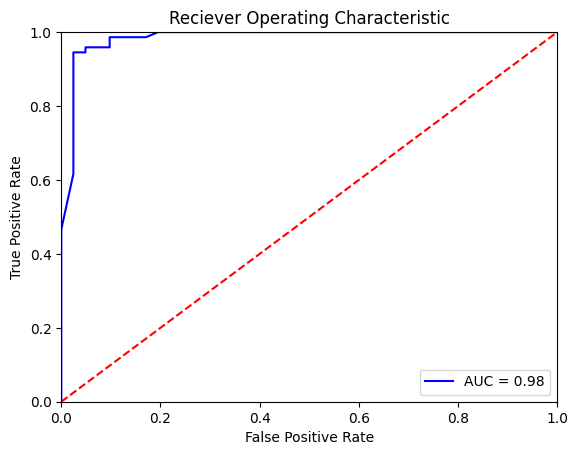

In [23]:
### ploting the ROC
Class_probabilites= classifier.predict_proba(X_test)
preds=Class_probabilites[:,1]
fpr,tpr,threshold=roc_curve(y_test,preds)
roc_auc=auc(fpr,tpr)


print(f"AUC for our classifier is: {roc_auc}")
plt.title('Reciever Operating Characteristic')
plt.plot(fpr,tpr,'b',label='AUC = %0.2f'% roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()


In [24]:
preds

array([1.  , 1.  , 1.  , 0.99, 1.  , 0.56, 0.  , 0.35, 0.1 , 1.  , 0.99,
       0.98, 0.99, 0.01, 1.  , 0.17, 0.53, 1.  , 1.  , 0.94, 0.  , 1.  ,
       0.99, 1.  , 0.16, 0.87, 0.98, 0.98, 0.01, 1.  , 0.  , 0.04, 0.08,
       0.  , 0.01, 1.  , 0.78, 1.  , 0.99, 1.  , 0.  , 1.  , 0.01, 0.06,
       1.  , 0.97, 0.39, 0.09, 0.95, 1.  , 0.  , 0.96, 1.  , 0.73, 0.  ,
       1.  , 0.88, 1.  , 1.  , 0.13, 0.  , 0.02, 0.98, 0.91, 1.  , 1.  ,
       0.  , 0.09, 1.  , 0.84, 1.  , 0.08, 1.  , 0.  , 1.  , 1.  , 0.93,
       0.85, 0.12, 0.65, 0.99, 1.  , 1.  , 0.01, 0.97, 0.03, 0.99, 0.  ,
       0.  , 0.99, 0.99, 1.  , 0.  , 1.  , 0.48, 0.15, 0.99, 1.  , 0.96,
       0.88, 0.25, 0.15, 0.99, 0.99, 0.  , 0.37, 0.  , 0.  , 0.75, 0.96,
       1.  , 0.97, 0.75, 0.  ])

In [25]:
Class_probabilites

array([[0.  , 1.  ],
       [0.  , 1.  ],
       [0.  , 1.  ],
       [0.01, 0.99],
       [0.  , 1.  ],
       [0.44, 0.56],
       [1.  , 0.  ],
       [0.65, 0.35],
       [0.9 , 0.1 ],
       [0.  , 1.  ],
       [0.01, 0.99],
       [0.02, 0.98],
       [0.01, 0.99],
       [0.99, 0.01],
       [0.  , 1.  ],
       [0.83, 0.17],
       [0.47, 0.53],
       [0.  , 1.  ],
       [0.  , 1.  ],
       [0.06, 0.94],
       [1.  , 0.  ],
       [0.  , 1.  ],
       [0.01, 0.99],
       [0.  , 1.  ],
       [0.84, 0.16],
       [0.13, 0.87],
       [0.02, 0.98],
       [0.02, 0.98],
       [0.99, 0.01],
       [0.  , 1.  ],
       [1.  , 0.  ],
       [0.96, 0.04],
       [0.92, 0.08],
       [1.  , 0.  ],
       [0.99, 0.01],
       [0.  , 1.  ],
       [0.22, 0.78],
       [0.  , 1.  ],
       [0.01, 0.99],
       [0.  , 1.  ],
       [1.  , 0.  ],
       [0.  , 1.  ],
       [0.99, 0.01],
       [0.94, 0.06],
       [0.  , 1.  ],
       [0.03, 0.97],
       [0.61, 0.39],
       [0.91,